# ANOMALY DETECTION

In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [75]:
FILE_PATH = "/content/cleaned_cicids2017.parquet"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Dataset not found: {FILE_PATH}")

df = pd.read_parquet(FILE_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Number of columns:", len(df.columns))

Dataset loaded successfully.
Shape: (2228970, 70)
Number of columns: 70


In [76]:
print("First 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes.value_counts())

print("\nLabel distribution:")
display(df["Label"].value_counts())

First 5 rows:


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,3.000000e+06,5.000000e+05,4.000000,0.000000,4,4,4,4.0,0.000000,4,4,0,0.000000,0.000000,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.00000,6.00000,0.0,2,12,0,0,329,0,1,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.0,0.000000,1,1,0,0.000000,0.000000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.00000,6.00000,0.0,2,12,0,0,329,0,1,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,4.000000e+06,6.666667e+05,3.000000,0.000000,3,3,3,3.0,0.000000,3,3,0,0.000000,0.000000,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.00000,6.00000,0.0,2,12,0,0,245,0,1,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.0,0.000000,1,1,0,0.000000,0.000000,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.00000,6.00000,0.0,2,12,0,0,245,0,1,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,207,0,103.5,119.511505,1.474548e+06,1.806240e+04,60.900002,115.194954,381,2,609,101.5,177.089523,460,2,467,155.666672,263.560883,460,3,0,0,164,104,1.149425e+04,6568.144531,0,233,74.833336,107.527443,11562.151367,0,0,0,1,0,0,0,0,0,81.63636,69.14286,103.5,7,484,4,414,8192,2053,5,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign



Data types:


,count
int32,26
float32,22
int8,11
int16,7
float64,2
int64,1
object,1



Label distribution:


,count
Label,
Benign,1892671
DoS Hulk,172688
DDoS,127995
DoS GoldenEye,10281
FTP-Patator,5927
DoS slowloris,5385
DoS Slowhttptest,5228
SSH-Patator,3217
PortScan,1956


In [77]:
# 0 = Benign
# 1 = Attack

df["is_attack"] = (df["Label"] != "Benign").astype(int)

print("Binary label distribution:")
print(df["is_attack"].value_counts())

print("\nPercentage distribution:")
print(
    df["is_attack"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Binary label distribution:
is_attack
0    1892671
1     336299
Name: count, dtype: int64

Percentage distribution:
is_attack
0    84.91
1    15.09
Name: proportion, dtype: float64


In [78]:
y = df["is_attack"].copy()

X = df.drop(columns=["Label", "is_attack"]).copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (2228970, 69)
Target shape: (2228970,)

Target distribution:
is_attack
0    1892671
1     336299
Name: count, dtype: int64


In [79]:
non_numeric_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of non-numeric features:", len(non_numeric_cols))

if non_numeric_cols:
    print("Non-numeric features:")
    print(non_numeric_cols)
else:
    print("All features are numeric.")

Number of non-numeric features: 0
All features are numeric.


In [80]:
# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

nan_before = X.isna().sum().sum()
inf_after_replace = np.isinf(X.to_numpy()).sum()

print("NaN values before handling:", nan_before)
print("Infinite values after replacement:", inf_after_replace)

# Fill missing values only if they exist
if nan_before > 0:
    X = X.fillna(X.median(numeric_only=True))

print("\nNaN values after handling:", X.isna().sum().sum())
print("Infinite values after handling:", np.isinf(X.to_numpy()).sum())

NaN values before handling: 0
Infinite values after replacement: 0

NaN values after handling: 0
Infinite values after handling: 0


In [81]:
constant_cols = X.columns[
    X.nunique() <= 1
].tolist()

print("Number of constant features:", len(constant_cols))

if constant_cols:
    print("Constant features:", constant_cols)
    X = X.drop(columns=constant_cols)

print("\nFinal feature matrix shape:", X.shape)

Number of constant features: 0

Final feature matrix shape: (2228970, 69)


In [82]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
Protocol,2228970.0,1.047658e+01,5.410576e+00,0.000000,6.000000,6.000000,1.700000e+01,1.700000e+01
Flow Duration,2228970.0,1.868932e+07,3.685743e+07,1.000000,2006.250000,76830.500000,6.039371e+06,1.200000e+08
Total Fwd Packets,2228970.0,6.823366e+00,8.368415e+01,1.000000,2.000000,2.000000,6.000000e+00,1.121410e+05
Total Backward Packets,2228970.0,6.826795e+00,1.158872e+02,0.000000,1.000000,2.000000,6.000000e+00,1.573880e+05
Fwd Packets Length Total,2228970.0,6.608314e+02,1.026370e+04,0.000000,39.000000,74.000000,3.640000e+02,1.290000e+07
Bwd Packets Length Total,2228970.0,6.770697e+03,2.820361e+05,0.000000,36.000000,190.000000,3.052000e+03,3.990000e+08
Fwd Packet Length Max,2228970.0,2.582295e+02,7.977190e+02,0.000000,27.000000,44.000000,3.040000e+02,2.482000e+04
Fwd Packet Length Min,2228970.0,2.140201e+01,6.427611e+01,0.000000,0.000000,6.000000,3.900000e+01,2.325000e+03
Fwd Packet Length Mean,2228970.0,7.041315e+01,2.056720e+02,0.000000,10.333333,40.000000,5.500000e+01,5.940857e+03
Fwd Packet Length Std,2228970.0,8.584373e+01,3.094172e+02,0.000000,0.000000,0.000000,9.332815e+01,7.125597e+03


In [83]:
# 70% Training
# 15% Validation
# 15% Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nValidation label distribution:")
print(y_val.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train shape     : (1560279, 69)
Validation shape: (334345, 69)
Test shape      : (334346, 69)

Training label distribution:
is_attack
0    1324870
1     235409
Name: count, dtype: int64

Validation label distribution:
is_attack
0    283900
1     50445
Name: count, dtype: int64

Test label distribution:
is_attack
0    283901
1     50445
Name: count, dtype: int64


In [84]:
# Isolation Forest is trained ONLY on benign traffic.
# Attack labels are NOT used during model fitting.

X_train_benign = X_train[y_train == 0]

print("Total training samples :", len(X_train))
print("Benign training samples:", len(X_train_benign))
print("Attack training samples:", (y_train == 1).sum())

Total training samples : 1560279
Benign training samples: 1324870
Attack training samples: 235409


In [85]:
MAX_TRAIN_SAMPLES = 500_000

if len(X_train_benign) > MAX_TRAIN_SAMPLES:
    X_train_benign_sample = X_train_benign.sample(
        n=MAX_TRAIN_SAMPLES,
        random_state=42
    )
else:
    X_train_benign_sample = X_train_benign.copy()

print(
    "Benign samples used for Isolation Forest training:",
    len(X_train_benign_sample)
)

Benign samples used for Isolation Forest training: 500000


In [86]:
baseline_iso = IsolationForest(
    n_estimators=200,
    max_samples=256,
    max_features=1.0,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

print("Baseline Isolation Forest configured.")

Baseline Isolation Forest configured.


In [87]:
baseline_iso.fit(X_train_benign_sample)

print("Baseline Isolation Forest trained successfully.")

Baseline Isolation Forest trained successfully.


In [88]:
val_scores_baseline = baseline_iso.decision_function(X_val)

print("Validation scores generated.")

print("\nScore statistics:")
print(pd.Series(val_scores_baseline).describe())

Validation scores generated.

Score statistics:
count    334345.000000
mean          0.099682
std           0.097063
min          -0.240176
25%           0.071193
50%           0.139522
75%           0.169807
max           0.181516
dtype: float64


In [89]:
val_pred_baseline = (
    baseline_iso.predict(X_val) == -1
).astype(int)

print("Baseline Validation Results")
print("=" * 50)

print(
    classification_report(
        y_val,
        val_pred_baseline,
        target_names=["Benign", "Attack"],
        digits=4
    )
)

baseline_roc = roc_auc_score(
    y_val,
    -val_scores_baseline
)

baseline_pr = average_precision_score(
    y_val,
    -val_scores_baseline
)

print(f"ROC-AUC: {baseline_roc:.4f}")
print(f"PR-AUC : {baseline_pr:.4f}")

Baseline Validation Results
              precision    recall  f1-score   support

      Benign     0.9284    0.9205    0.9245    283900
      Attack     0.5732    0.6006    0.5866     50445

    accuracy                         0.8723    334345
   macro avg     0.7508    0.7606    0.7555    334345
weighted avg     0.8748    0.8723    0.8735    334345

ROC-AUC: 0.8721
PR-AUC : 0.5966


In [90]:
threshold_results = []

# Evaluate thresholds corresponding to the
# 1st to 29th percentile of validation scores.

for percentile in np.arange(1, 30):

    threshold = np.percentile(
        val_scores_baseline,
        percentile
    )

    # Lower score = anomaly
    pred = (
        val_scores_baseline < threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred
    ).ravel()

    fpr = fp / (fp + tn)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "anomaly_percentage": pred.mean() * 100
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df
    .sort_values("f1", ascending=False)
    .head(10)
)

,percentile,threshold,precision,recall,f1,fpr,anomaly_percentage
18,19,0.019860,0.589160,0.741937,0.656781,0.091930,19.000135
17,18,0.011042,0.594447,0.709188,0.646768,0.085970,17.999970
19,20,0.033752,0.564626,0.748459,0.643674,0.102547,20.000000
20,21,0.044718,0.539914,0.751492,0.628371,0.113787,21.000165
16,17,0.004634,0.588188,0.662742,0.623243,0.082448,17.000105
21,22,0.054401,0.517769,0.754981,0.614269,0.124942,22.000030
8,9,-0.102655,0.810176,0.483279,0.605419,0.020120,8.999985
22,23,0.061027,0.496788,0.757320,0.599992,0.136305,23.000194
9,10,-0.075457,0.745446,0.494083,0.594278,0.029979,10.000150
15,16,0.000696,0.576024,0.610863,0.592933,0.079891,16.000239


In [91]:
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

BEST_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print("Best threshold based on validation F1")
print("=" * 45)

print(f"Threshold            : {BEST_THRESHOLD:.6f}")
print(f"Precision            : {best_threshold_row['precision']:.4f}")
print(f"Recall               : {best_threshold_row['recall']:.4f}")
print(f"F1-score             : {best_threshold_row['f1']:.4f}")
print(f"False Positive Rate  : {best_threshold_row['fpr']:.4f}")
print(
    f"Predicted anomalies  : "
    f"{best_threshold_row['anomaly_percentage']:.2f}%"
)

Best threshold based on validation F1
Threshold            : 0.019860
Precision            : 0.5892
Recall               : 0.7419
F1-score             : 0.6568
False Positive Rate  : 0.0919
Predicted anomalies  : 19.00%


In [92]:
val_pred_tuned = (
    val_scores_baseline < BEST_THRESHOLD
).astype(int)

print("Baseline + Tuned Threshold")
print("=" * 45)

print(
    classification_report(
        y_val,
        val_pred_tuned,
        target_names=["Benign", "Attack"],
        digits=4
    )
)

Baseline + Tuned Threshold
              precision    recall  f1-score   support

      Benign     0.9519    0.9081    0.9295    283900
      Attack     0.5892    0.7419    0.6568     50445

    accuracy                         0.8830    334345
   macro avg     0.7705    0.8250    0.7931    334345
weighted avg     0.8972    0.8830    0.8883    334345



In [93]:
experiments = [
    {
        "name": "IF_100_256",
        "n_estimators": 100,
        "max_samples": 256
    },
    {
        "name": "IF_200_256",
        "n_estimators": 200,
        "max_samples": 256
    },
    {
        "name": "IF_300_256",
        "n_estimators": 300,
        "max_samples": 256
    },
    {
        "name": "IF_200_512",
        "n_estimators": 200,
        "max_samples": 512
    },
    {
        "name": "IF_200_1024",
        "n_estimators": 200,
        "max_samples": 1024
    }
]

experiment_results = []

for exp in experiments:

    print(f"\nTraining {exp['name']}...")

    model = IsolationForest(
        n_estimators=exp["n_estimators"],
        max_samples=exp["max_samples"],
        max_features=1.0,
        contamination="auto",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_benign_sample)

    scores = model.decision_function(X_val)

    best_f1 = -1
    best_threshold = None
    best_precision = None
    best_recall = None
    best_fpr = None

    for percentile in np.arange(1, 30):

        threshold = np.percentile(
            scores,
            percentile
        )

        pred = (
            scores < threshold
        ).astype(int)

        precision = precision_score(
            y_val,
            pred,
            zero_division=0
        )

        recall = recall_score(
            y_val,
            pred,
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            pred,
            zero_division=0
        )

        tn, fp, fn, tp = confusion_matrix(
            y_val,
            pred
        ).ravel()

        fpr = fp / (fp + tn)

        if f1 > best_f1:

            best_f1 = f1
            best_threshold = threshold
            best_precision = precision
            best_recall = recall
            best_fpr = fpr

    roc = roc_auc_score(
        y_val,
        -scores
    )

    pr = average_precision_score(
        y_val,
        -scores
    )

    experiment_results.append({
        "model": exp["name"],
        "n_estimators": exp["n_estimators"],
        "max_samples": exp["max_samples"],
        "ROC_AUC": roc,
        "PR_AUC": pr,
        "Precision": best_precision,
        "Recall": best_recall,
        "F1": best_f1,
        "FPR": best_fpr,
        "threshold": best_threshold
    })

experiment_df = pd.DataFrame(
    experiment_results
)

display(
    experiment_df
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)


Training IF_100_256...

Training IF_200_256...

Training IF_300_256...

Training IF_200_512...

Training IF_200_1024...


,model,n_estimators,max_samples,ROC_AUC,PR_AUC,Precision,Recall,F1,FPR,threshold
0,IF_200_1024,200,1024,0.885998,0.682168,0.640704,0.721915,0.678890,0.071934,0.032042
1,IF_200_512,200,512,0.882294,0.640644,0.619371,0.738924,0.673886,0.080687,0.029071
2,IF_100_256,100,256,0.872496,0.595821,0.591301,0.744633,0.659168,0.091451,0.015666
3,IF_300_256,300,256,0.873777,0.596952,0.590703,0.743879,0.658501,0.091585,0.015098
4,IF_200_256,200,256,0.872101,0.596590,0.589160,0.741937,0.656781,0.091930,0.019860


In [94]:
best_experiment = experiment_df.loc[
    experiment_df["F1"].idxmax()
]

FINAL_N_ESTIMATORS = int(
    best_experiment["n_estimators"]
)

FINAL_MAX_SAMPLES = int(
    best_experiment["max_samples"]
)

FINAL_MAX_FEATURES = 1.0

FINAL_THRESHOLD = float(
    best_experiment["threshold"]
)

print("FINAL CONFIGURATION")
print("=" * 40)

print("n_estimators :", FINAL_N_ESTIMATORS)
print("max_samples  :", FINAL_MAX_SAMPLES)
print("max_features :", FINAL_MAX_FEATURES)
print(f"threshold    : {FINAL_THRESHOLD:.6f}")

FINAL CONFIGURATION
n_estimators : 200
max_samples  : 1024
max_features : 1.0
threshold    : 0.032042


In [95]:
final_iso = IsolationForest(
    n_estimators=FINAL_N_ESTIMATORS,
    max_samples=FINAL_MAX_SAMPLES,
    max_features=FINAL_MAX_FEATURES,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

final_iso.fit(X_train_benign_sample)

print("Final Isolation Forest trained successfully.")

Final Isolation Forest trained successfully.


In [96]:
# The test set is used only for final evaluation.

final_test_scores = final_iso.decision_function(
    X_test
)

final_test_pred = (
    final_test_scores < FINAL_THRESHOLD
).astype(int)

print("Final test predictions generated.")
print("Number of test samples:", len(X_test))

Final test predictions generated.
Number of test samples: 334346


In [97]:
print("FINAL ISOLATION FOREST — HELD-OUT TEST RESULTS")
print("=" * 60)

print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=["Benign", "Attack"],
        digits=4
    )
)

final_roc_auc = roc_auc_score(
    y_test,
    -final_test_scores
)

final_pr_auc = average_precision_score(
    y_test,
    -final_test_scores
)

final_precision = precision_score(
    y_test,
    final_test_pred
)

final_recall = recall_score(
    y_test,
    final_test_pred
)

final_f1 = f1_score(
    y_test,
    final_test_pred
)

print(f"ROC-AUC : {final_roc_auc:.4f}")
print(f"PR-AUC  : {final_pr_auc:.4f}")
print(f"Attack Precision : {final_precision:.4f}")
print(f"Attack Recall    : {final_recall:.4f}")
print(f"Attack F1        : {final_f1:.4f}")

FINAL ISOLATION FOREST — HELD-OUT TEST RESULTS
              precision    recall  f1-score   support

      Benign     0.9499    0.9271    0.9384    283901
      Attack     0.6386    0.7250    0.6791     50445

    accuracy                         0.8966    334346
   macro avg     0.7943    0.8261    0.8087    334346
weighted avg     0.9030    0.8966    0.8993    334346

ROC-AUC : 0.8862
PR-AUC  : 0.6801
Attack Precision : 0.6386
Attack Recall    : 0.7250
Attack F1        : 0.6791


Confusion Matrix:
[[263207  20694]
 [ 13871  36574]]


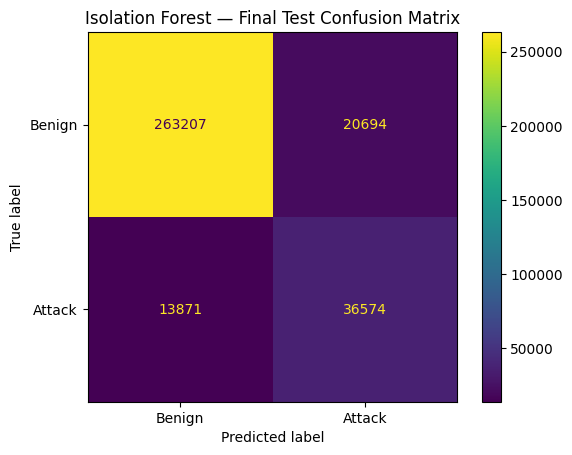

In [98]:
cm = confusion_matrix(
    y_test,
    final_test_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Attack"]
)

disp.plot()

plt.title(
    "Isolation Forest — Final Test Confusion Matrix"
)

plt.show()

In [99]:
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("FINAL ERROR ANALYSIS")
print("=" * 45)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print(f"\nFalse Positive Rate: {fpr:.4f}")
print(f"False Negative Rate: {fnr:.4f}")

print(f"\nAttack Precision: {tp / (tp + fp):.4f}")
print(f"Attack Recall   : {tp / (tp + fn):.4f}")

FINAL ERROR ANALYSIS
True Negatives : 263207
False Positives: 20694
False Negatives: 13871
True Positives  : 36574

False Positive Rate: 0.0729
False Negative Rate: 0.2750

Attack Precision: 0.6386
Attack Recall   : 0.7250


In [100]:
test_analysis = df.loc[X_test.index].copy()

test_analysis["predicted_anomaly"] = final_test_pred
test_analysis["anomaly_score"] = final_test_scores

attack_only = test_analysis[
    test_analysis["is_attack"] == 1
].copy()

attack_detection = (
    attack_only
    .groupby("Label")["predicted_anomaly"]
    .agg(
        total_samples="count",
        detected="sum"
    )
)

attack_detection["detection_rate"] = (
    attack_detection["detected"] /
    attack_detection["total_samples"]
)

attack_detection = attack_detection.sort_values(
    "detection_rate",
    ascending=False
)

display(attack_detection)

,total_samples,detected,detection_rate
Label,,,
Infiltration,7,7,1.000000
DoS Hulk,26010,23099,0.888082
DoS Slowhttptest,813,696,0.856089
DoS slowloris,776,475,0.612113
DDoS,19113,11347,0.593680
DoS GoldenEye,1550,892,0.575484
PortScan,301,40,0.132890
Web Attack - Brute Force,212,12,0.056604
Web Attack - XSS,92,2,0.021739


In [101]:
test_analysis = df.loc[X_test.index].copy()

test_analysis["predicted_anomaly"] = final_test_pred
test_analysis["anomaly_score"] = final_test_scores

attack_only = test_analysis[
    test_analysis["is_attack"] == 1
].copy()

attack_detection = (
    attack_only
    .groupby("Label")["predicted_anomaly"]
    .agg(
        total_samples="count",
        detected="sum"
    )
)

attack_detection["detection_rate"] = (
    attack_detection["detected"] /
    attack_detection["total_samples"]
)

attack_detection = attack_detection.sort_values(
    "detection_rate",
    ascending=False
)

display(attack_detection)

,total_samples,detected,detection_rate
Label,,,
Infiltration,7,7,1.000000
DoS Hulk,26010,23099,0.888082
DoS Slowhttptest,813,696,0.856089
DoS slowloris,776,475,0.612113
DDoS,19113,11347,0.593680
DoS GoldenEye,1550,892,0.575484
PortScan,301,40,0.132890
Web Attack - Brute Force,212,12,0.056604
Web Attack - XSS,92,2,0.021739


In [102]:
print("FINAL ISOLATION FOREST SUMMARY")
print("=" * 60)

print("\nDATA")
print("-" * 30)
print("Dataset             : CICIDS2017")
print("Total flows         :", len(df))
print("Features used       :", X.shape[1])

print("\nTRAINING")
print("-" * 30)
print("Training approach   : Benign-only")
print("Benign training samples:", len(X_train_benign_sample))

print("\nMODEL")
print("-" * 30)
print("Algorithm           : Isolation Forest")
print("n_estimators        :", FINAL_N_ESTIMATORS)
print("max_samples         :", FINAL_MAX_SAMPLES)
print("max_features        :", FINAL_MAX_FEATURES)
print("contamination       : auto")
print("random_state        : 42")

print("\nTHRESHOLD")
print("-" * 30)
print(f"Selected threshold  : {FINAL_THRESHOLD:.6f}")

print("\nHELD-OUT TEST")
print("-" * 30)
print(f"ROC-AUC             : {final_roc_auc:.4f}")
print(f"PR-AUC              : {final_pr_auc:.4f}")
print(f"Attack Precision    : {final_precision:.4f}")
print(f"Attack Recall       : {final_recall:.4f}")
print(f"Attack F1           : {final_f1:.4f}")
print(f"False Positive Rate : {fpr:.4f}")
print(f"False Negative Rate : {fnr:.4f}")

FINAL ISOLATION FOREST SUMMARY

DATA
------------------------------
Dataset             : CICIDS2017
Total flows         : 2228970
Features used       : 69

TRAINING
------------------------------
Training approach   : Benign-only
Benign training samples: 500000

MODEL
------------------------------
Algorithm           : Isolation Forest
n_estimators        : 200
max_samples         : 1024
max_features        : 1.0
contamination       : auto
random_state        : 42

THRESHOLD
------------------------------
Selected threshold  : 0.032042

HELD-OUT TEST
------------------------------
ROC-AUC             : 0.8862
PR-AUC              : 0.6801
Attack Precision    : 0.6386
Attack Recall       : 0.7250
Attack F1           : 0.6791
False Positive Rate : 0.0729
False Negative Rate : 0.2750


In [ ]:
detection_results.to_csv(
    '/content/cicids_isolation_forest_results.csv',
    index=False
)

print("Saved successfully.")